In [16]:
import pandas as pd
import numpy as np

# aggregated_results is produced by gencsv.py, which read all SUMMARY_* files and parse them into one CSV
# aggregated_results_new.csv now contains re-ran data for all 6 subjects, with ENHANCED/REDUCED results for FIX scenario, but deepseek-r1 result is in other old csv
data_path = "aggregated_results_10rep_enhance.csv"
data = pd.read_csv(data_path)
data.head()

,file,scenario,git_info,max_iter,LLM,LLM_temp,NOFEEDBACK,GENCMD,RUNFUZZ,subject,commit,final_result,unintended_bug,time,iid,score,success
0,SUMMARY_jerryscript_BIC_GITDIFFONLY_ITER5_gpt-...,BIC,DIFFONLY,5,gpt-4o-2024-08-06,0.5,NaN,NaN,NaN,jerryscript,b7e3bae,R,False,100,5013,1,0
1,SUMMARY_jerryscript_BIC_GITDIFFONLY_ITER5_gpt-...,BIC,DIFFONLY,5,gpt-4o-2024-08-06,0.5,NaN,NaN,NaN,jerryscript,70e275e,D,False,97,5138,2,0
2,SUMMARY_jerryscript_BIC_GITDIFFONLY_ITER5_gpt-...,BIC,DIFFONLY,5,gpt-4o-2024-08-06,0.5,NaN,NaN,NaN,jerryscript,53b61c1,D,False,57,5117,2,0
3,SUMMARY_jerryscript_BIC_GITDIFFONLY_ITER5_gpt-...,BIC,DIFFONLY,5,gpt-4o-2024-08-06,0.5,NaN,NaN,NaN,jerryscript,70e275e,B,False,36,5153,3,1
4,SUMMARY_jerryscript_BIC_GITDIFFONLY_ITER5_gpt-...,BIC,DIFFONLY,5,gpt-4o-2024-08-06,0.5,NaN,NaN,NaN,jerryscript,b7e3bae,R,False,107,5013,1,0


In [17]:
# config for default
config_def = {
    "git_info": "FULL",
    "max_iter": 5,
    "LLM": "gpt-4o-2024-08-06",
    "LLM_temp": 0.5,
    "NOFEEDBACK": np.nan,
    "GENCMD": np.nan,
}

In [18]:
config_prompt_msg = config_def.copy()
config_prompt_msg["git_info"] = "MSGONLY"
config_prompt_diff = config_def.copy()
config_prompt_diff["git_info"] = "DIFFONLY"
config_prompt_enhanced = config_def.copy()
config_prompt_enhanced["git_info"] = "ENHANCED"
config_prompt_reduced = config_def.copy()
config_prompt_reduced["git_info"] = "REDUCED"


configs = {
    "prompt-msg": config_prompt_msg,
    "prompt-enhanced": config_prompt_enhanced,
    "prompt-reduced": config_prompt_reduced,
}

data_each_config = []
for config_key, config in configs.items():
    data_config = data.copy()
    for key, value in config.items():
        if pd.isna(value):
            data_config = data_config[pd.isna(data_config[key])]
        else:
            data_config = data_config[data_config[key] == value]
    data_config = data_config[data_config["scenario"] == "FIX"]
    data_config = (
        data_config.groupby(["scenario", "subject", "iid"])
        .agg({"score": "mean"})
        .reset_index()
    )
    data_config["config_category"] = config_key.split("-")[0]
    data_config["config"] = config_key.split("-")[1]
    data_each_config.append(data_config)

data_each_config = pd.concat(data_each_config)
data_each_config = data_each_config.pivot(
    index=["scenario", "subject", "iid"],
    columns=["config_category", "config"],
    values="score",
)

# TODO: ENHANCE/REDUCED only needed for "final_result" column is not "B" or "N"/"X"?

# dfs = []
# # add average row for each scenario
# for scenario in data_each_config.index.levels[0]:
#     sub_data = data_each_config.loc[
#         data_each_config.index.get_level_values(0) == scenario
#     ]
#     average = sub_data.agg("mean").to_frame().T
#     average.index = pd.MultiIndex.from_tuples([(scenario, "Average", "")])
#     dfs = dfs + [sub_data, average]
# data_each_config = pd.concat(dfs)
data_each_config.index = pd.MultiIndex.from_arrays(
    [
        pd.Categorical(
            data_each_config.index.get_level_values(0),
            categories=["FIX"],
            ordered=True,
        ),
        pd.Categorical(
            data_each_config.index.get_level_values(1),
            categories=[
                "mujs",
                "libxml2",
                "poppler",
                "jerryscript",
                "z3",
                "php-src",
                "Average",
            ],
            ordered=True,
        ),
        data_each_config.index.get_level_values(2),
    ]
)
data_each_config = data_each_config.sort_index()
# NOTE: FIX poppler 1305 (prompt, msg) data 0.2 is wrong, manually set to 0.0
data_each_config.loc[("FIX", "poppler", 1305), ("prompt", "msg")] = 0.0
data_each_config

config_category       prompt                 
config                   msg enhanced reduced
                iid                          
FIX mujs        65       1.0      3.0     1.0
                141      0.0      3.0     0.0
                145      2.4      3.0     1.8
                166      3.0      3.0     1.6
    libxml2     535      3.0      3.0     3.0
                550      0.0      0.0     0.0
    poppler     1282     1.0      0.9     1.0
                1289     0.0      2.1     0.0
                1303     0.0      1.6     0.0
                1305     0.0      0.0     0.1
                1381     0.0      0.0     0.0
    jerryscript 5013     1.0      1.0     0.0
                5117     1.4      2.8     1.0
                5138     1.0      3.0     1.0
                5153     0.0      1.2     0.0
    z3          6659     0.0      0.9     0.0
                6914     0.2      0.7     0.0
                7246     0.0      0.0     0.0
                7252     0.0      1.6     0.0
    php-src     16777    0.6      0.7     0.0
                16978    0.0      0.2     0.0
                17442    0.0      0.0     0.0
                17463    3.0      3.0     3.0

In [19]:
freq_dict = {}
for i, row in data_each_config.iterrows():  # type: ignore
    # msg: x
    # enhanced: y1
    # reduced: y2
    # print(row)
    msg = float(row[("prompt", "msg")])  # type: ignore
    enhanced = float(row[("prompt", "enhanced")])  # type: ignore
    reduced = float(row[("prompt", "reduced")])  # type: ignore
    if msg != 3:
        key1 = (msg, enhanced, "Enhancement")
        if key1 not in freq_dict:
            freq_dict[key1] = 0
        freq_dict[key1] += 1
    else:
        print(f"Don't do enhanced: {row.name}, {row.to_dict()}")
    if msg != 0:
        key2 = (msg, reduced, "Reduction")
        if key2 not in freq_dict:
            freq_dict[key2] = 0
        freq_dict[key2] += 1
    else:
        print(f"Don't do reduced: {row.name}, {row.to_dict()}")
freq_data = [(*key, freq) for key, freq in freq_dict.items()]
freq_df = pd.DataFrame(
    freq_data, columns=["orig", "update", "type", "frequency"]
)
display(freq_df)
print(
    "Num enhanced:", freq_df[freq_df["type"] == "Enhancement"]["frequency"].sum()
)
print(
    "Num reduced:", freq_df[freq_df["type"] == "Reduction"]["frequency"].sum()
)

Don't do reduced: ('FIX', 'mujs', 141), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 3.0, ('prompt', 'reduced'): 0.0}
Don't do enhanced: ('FIX', 'mujs', 166), {('prompt', 'msg'): 3.0, ('prompt', 'enhanced'): 3.0, ('prompt', 'reduced'): 1.6}
Don't do enhanced: ('FIX', 'libxml2', 535), {('prompt', 'msg'): 3.0, ('prompt', 'enhanced'): 3.0, ('prompt', 'reduced'): 3.0}
Don't do reduced: ('FIX', 'libxml2', 550), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 0.0, ('prompt', 'reduced'): 0.0}
Don't do reduced: ('FIX', 'poppler', 1289), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 2.1, ('prompt', 'reduced'): 0.0}
Don't do reduced: ('FIX', 'poppler', 1303), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 1.6, ('prompt', 'reduced'): 0.0}
Don't do reduced: ('FIX', 'poppler', 1305), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 0.0, ('prompt', 'reduced'): 0.1}
Don't do reduced: ('FIX', 'poppler', 1381), {('prompt', 'msg'): 0.0, ('prompt', 'enhanced'): 0.0, ('prompt', 'reduced'): 0.0}


,orig,update,type,frequency
0,1.0,3.0,Enhancement,2
1,1.0,1.0,Reduction,3
2,0.0,3.0,Enhancement,1
3,2.4,3.0,Enhancement,1
4,2.4,1.8,Reduction,1
5,3.0,1.6,Reduction,1
6,3.0,3.0,Reduction,2
7,0.0,0.0,Enhancement,5
8,1.0,0.9,Enhancement,1
9,0.0,2.1,Enhancement,1


Num enhanced: 20
Num reduced: 11


In [20]:
freq_df

,orig,update,type,frequency
0,1.0,3.0,Enhancement,2
1,1.0,1.0,Reduction,3
2,0.0,3.0,Enhancement,1
3,2.4,3.0,Enhancement,1
4,2.4,1.8,Reduction,1
5,3.0,1.6,Reduction,1
6,3.0,3.0,Reduction,2
7,0.0,0.0,Enhancement,5
8,1.0,0.9,Enhancement,1
9,0.0,2.1,Enhancement,1


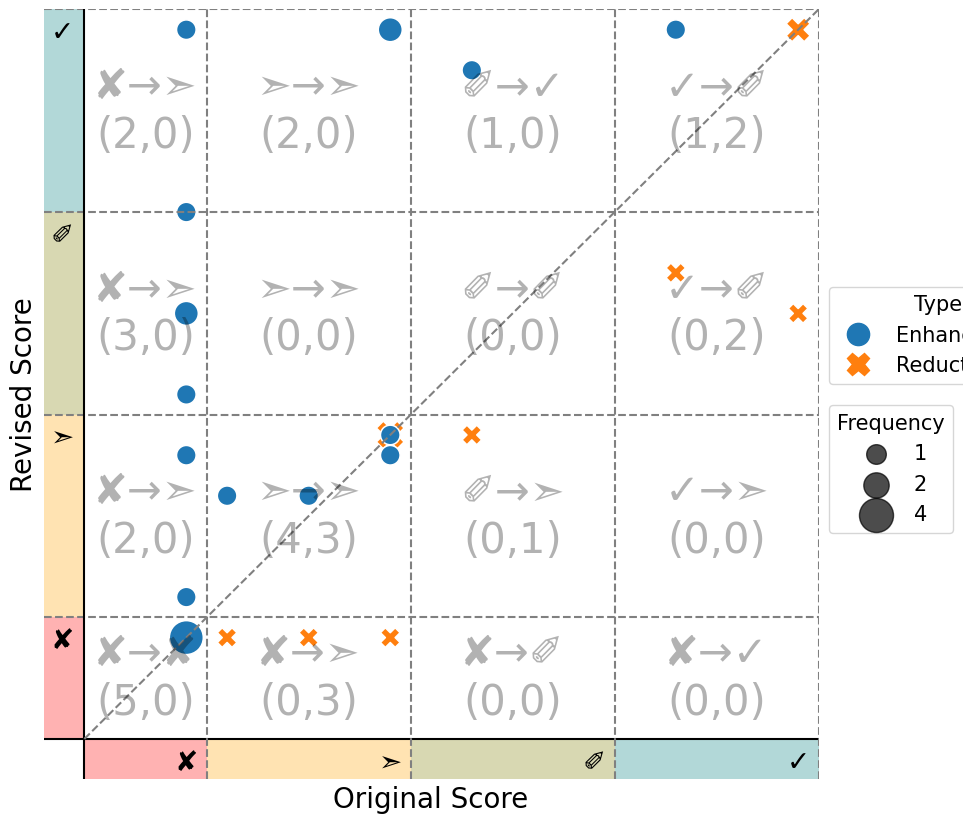

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(
    data=freq_df,
    x="orig",
    y="update",
    hue="type",
    style="type",
    size="frequency",
    sizes=(200, 600),
    ax=ax,
    legend=False,
)
# lim
plt.xlim(-0.7, 3.1)
plt.ylim(-0.7, 3.1)
# axis ticks: [0, 1, 2, 3]
plt.xticks([0, 1, 2, 3])
plt.yticks([0, 1, 2, 3])
# horizontal line at y=0.1
plt.axhline(y=-0.5, color="black", linestyle="-")
plt.axhline(y=0.1, color="gray", linestyle="--")
plt.axhline(y=1.1, color="gray", linestyle="--")
plt.axhline(y=2.1, color="gray", linestyle="--")
plt.axhline(y=3.1, color="gray", linestyle="--")
plt.axvline(x=-0.5, color="black", linestyle="-")
plt.axvline(x=0.1, color="gray", linestyle="--")
plt.axvline(x=1.1, color="gray", linestyle="--")
plt.axvline(x=2.1, color="gray", linestyle="--")
plt.axvline(x=3.1, color="gray", linestyle="--")
# diagonal line
plt.plot([-0.5, 3.1], [-0.5, 3.1], color="gray", linestyle="--")

rectx1 = patches.Rectangle(
    (-0.5, -0.7),
    0.6,
    0.2,
    linewidth=0,
    edgecolor="red",
    facecolor="red",
    alpha=0.3,
)
rectx2 = patches.Rectangle(
    (0.1, -0.7),
    1.0,
    0.2,
    linewidth=0,
    edgecolor="orange",
    facecolor="orange",
    alpha=0.3,
)
rectx3 = patches.Rectangle(
    (1.1, -0.7),
    1.0,
    0.2,
    linewidth=0,
    edgecolor="olive",
    facecolor="olive",
    alpha=0.3,
)
rectx4 = patches.Rectangle(
    (2.1, -0.7),
    1.0,
    0.2,
    linewidth=0,
    edgecolor="teal",
    facecolor="teal",
    alpha=0.3,
)
recty1 = patches.Rectangle(
    (-0.7, -0.5),
    0.2,
    0.6,
    linewidth=0,
    edgecolor="red",
    facecolor="red",
    alpha=0.3,
)
recty2 = patches.Rectangle(
    (-0.7, 0.1),
    0.2,
    1.0,
    linewidth=0,
    edgecolor="orange",
    facecolor="orange",
    alpha=0.3,
)
recty3 = patches.Rectangle(
    (-0.7, 1.1),
    0.2,
    1.0,
    linewidth=0,
    edgecolor="olive",
    facecolor="olive",
    alpha=0.3,
)
recty4 = patches.Rectangle(
    (-0.7, 2.1),
    0.2,
    1.0,
    linewidth=0,
    edgecolor="teal",
    facecolor="teal",
    alpha=0.3,
)

ax.add_patch(rectx1)
ax.add_patch(rectx2)
ax.add_patch(rectx3)
ax.add_patch(rectx4)
ax.add_patch(recty1)
ax.add_patch(recty2)
ax.add_patch(recty3)
ax.add_patch(recty4)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0, direction="in", pad=-22, labelsize=20)
ax.tick_params(axis="y", length=0, direction="in", pad=-22, labelsize=20)
# x tick label
ax.set_xticklabels(
    ["✘", "➣", "✐", "✓"],
)
ax.set_yticklabels(
    ["✘", "➣", "✐", "✓"],
)
# ax.text(-0.32, -0.45, "✘", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(-0.2, -0.45, "→", fontsize=20, ha="center", va="bottom")
# ax.text(-0.08, -0.45, "✘", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (freq_df["orig"] == 0.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (freq_df["orig"] == 0.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
ax.text(
    -0.2,
    -0.2,
    f"✘→✘\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(0.48, -0.45, "✘", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(0.6, -0.45, "→", fontsize=20, ha="center", va="bottom")
# ax.text(0.72, -0.45, "➣", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
ax.text(
    0.6,
    -0.2,
    f"✘→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(1.48, -0.45, "✘", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(1.6, -0.45, "→", fontsize=20, ha="center", va="bottom")
# ax.text(1.72, -0.45, "✐", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
ax.text(
    1.6,
    -0.2,
    f"✘→✐\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(2.48, -0.45, "✘", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(2.6, -0.45, "→", fontsize=20, ha="center", va="bottom")
# ax.text(2.72, -0.45, "✓", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (2.0 < freq_df["orig"])
    & (freq_df["orig"] <= 3.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (2.0 < freq_df["orig"])
    & (freq_df["orig"] <= 3.0)
    & (freq_df["update"] == 0.0)
]["frequency"].sum()
ax.text(
    2.6,
    -0.2,
    f"✘→✓\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(-0.32, 0.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(-0.2, 0.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(-0.08, 0.15, "✘", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (freq_df["orig"] == 0.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (freq_df["orig"] == 0.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
ax.text(
    -0.2,
    0.6,
    f"✘→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(0.48, 0.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(0.6, 0.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(0.72, 0.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
ax.text(
    0.6,
    0.6,
    f"➣→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(1.48, 0.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(1.6, 0.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(1.72, 0.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
ax.text(
    1.6,
    0.6,
    f"✐→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(2.48, 0.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(2.6, 0.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(2.72, 0.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (2.0 < freq_df["orig"])
    & (freq_df["orig"] <= 3.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (2.0 < freq_df["orig"])
    & (freq_df["orig"] <= 3.0)
    & (0.0 < freq_df["update"])
    & (freq_df["update"] <= 1.0)
]["frequency"].sum()
ax.text(
    2.6,
    0.6,
    f"✓→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(-0.32, 1.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(-0.2, 1.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(-0.08, 1.15, "✘", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (freq_df["orig"] == 0.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (freq_df["orig"] == 0.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
ax.text(
    -0.2,
    1.6,
    f"✘→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(0.48, 1.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(0.6, 1.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(0.72, 1.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
ax.text(
    0.6,
    1.6,
    f"➣→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(1.48, 1.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(1.6, 1.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(1.72, 1.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
ax.text(
    1.6,
    1.6,
    f"✐→✐\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(2.48, 1.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(2.6, 1.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(2.72, 1.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (2.0 < freq_df["orig"])
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (2.0 < freq_df["orig"])
    & (1.0 < freq_df["update"])
    & (freq_df["update"] <= 2.0)
]["frequency"].sum()
ax.text(
    2.6,
    1.6,
    f"✓→✐\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(-0.32, 2.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(-0.2, 2.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(-0.08, 2.15, "✘", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (freq_df["orig"] == 0.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (freq_df["orig"] == 0.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
ax.text(
    -0.2,
    2.6,
    f"✘→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(0.48, 2.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(0.6, 2.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(0.72, 2.15, "➣", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (0.0 < freq_df["orig"])
    & (freq_df["orig"] <= 1.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
ax.text(
    0.6,
    2.6,
    f"➣→➣\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(1.48, 2.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(1.6, 2.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(1.72, 2.15, "✐", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (1.0 < freq_df["orig"])
    & (freq_df["orig"] <= 2.0)
    & (2.0 < freq_df["update"])
]["frequency"].sum()
ax.text(
    1.6,
    2.6,
    f"✐→✓\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)
# ax.text(2.48, 2.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
# ax.text(2.6, 2.15, "→", fontsize=20, ha="center", va="bottom")
# ax.text(2.72, 2.15, "✓", fontsize=20, ha="center", va="bottom", color="black")
num_e = freq_df[
    (freq_df["type"] == "Enhancement")
    & (2.0 < freq_df["orig"])
    & (2.0 < freq_df["update"])
]["frequency"].sum()
num_r = freq_df[
    (freq_df["type"] == "Reduction")
    & (2.0 < freq_df["orig"])
    & (2.0 < freq_df["update"])
]["frequency"].sum()
ax.text(
    2.6,
    2.6,
    f"✓→✐\n({num_e},{num_r})",
    fontsize=30,
    ha="center",
    va="center",
    alpha=0.3,
)

ax.set_xlabel("Original Score", fontsize=20)
ax.set_ylabel("Revised Score", fontsize=20)

# legend
# legend = ax.legend(
#     fontsize=15,
#     bbox_to_anchor=(1, .5),
# )
from matplotlib.lines import Line2D

pal = {
    "Enhancement": sns.color_palette()[0],
    "Reduction": sns.color_palette()[1],
}
markers = {"Enhancement": "o", "Reduction": "X"}

type_handles = [
    Line2D(
        [0],
        [0],
        marker=markers["Enhancement"],
        linestyle="",
        markerfacecolor=pal["Enhancement"],
        markeredgecolor=pal["Enhancement"],
        markersize=16,
        label="Enhancement",
    ),
    Line2D(
        [0],
        [0],
        marker=markers["Reduction"],
        linestyle="",
        markerfacecolor=pal["Reduction"],
        markeredgecolor=pal["Reduction"],
        markersize=16,
        label="Reduction",
    ),
]
leg1 = ax.legend(handles=type_handles, title="Type", title_fontsize=15, fontsize=15, bbox_to_anchor=(1, 0.5), loc="lower left")
ax.add_artist(leg1)

def size_to_area(v, vmin=1, vmax=4, smin=200, smax=600):
    return smin + (v - vmin) * (smax - smin) / (vmax - vmin)

for v in [1, 2, 4]:
    ax.scatter([], [], s=size_to_area(v), c="k", alpha=0.7, label=str(v))
ax.legend(title="Frequency", fontsize=15, title_fontsize=15, bbox_to_anchor=(1, 0.5), loc="upper left")


plt.savefig("rq3.pdf", bbox_inches="tight")
plt.show()